In [8]:
# %pip install pandas numpy

In [9]:
import pandas as pd
import numpy as np

# Read raw appointment data
df = pd.read_csv("../Data/raw/KaggleV2-May-2016.csv")

# Preview the first few rows
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [10]:
df.shape

(110527, 14)

In [11]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


## Data Cleaning

Before beginning the analysis, I standardized the column names to improve readability and make the dataset easier to work with in Python and SQL.  

This included:
- Converting column names to snake_case
- Correcting spelling inconsistencies such as `Hipertension` to `hypertension`
- Replacing the hyphenated target variable `No-show` with `no_show`

In [13]:
# Rename columns for consistency and readability
df = df.rename(columns={
    "PatientId": "patient_id",
    "AppointmentID": "appointment_id",
    "Gender": "gender",
    "ScheduledDay": "scheduled_day",
    "AppointmentDay": "appointment_day",
    "Age": "age",
    "Neighbourhood": "neighbourhood",
    "Scholarship": "scholarship",
    "Hipertension": "hypertension",
    "Diabetes": "diabetes",
    "Alcoholism": "alcoholism",
    "Handcap": "handicap",
    "SMS_received": "sms_received",
    "No-show": "no_show"
})

df.columns

Index(['patient_id', 'appointment_id', 'gender', 'scheduled_day',
       'appointment_day', 'age', 'neighbourhood', 'scholarship',
       'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received',
       'no_show'],
      dtype='str')

### Date Conversion and Waiting Time

The scheduling and appointment date columns were originally stored as text, so I converted them into datetime format for time-based analysis.  

I also created a new feature, `waiting_days`, which measures the number of days between when an appointment was scheduled and when it was expected to occur. This variable will help evaluate whether longer lead times are associated with higher no-show rates.

In [14]:
# Convert date columns to datetime format
df["scheduled_day"] = pd.to_datetime(df["scheduled_day"])
df["appointment_day"] = pd.to_datetime(df["appointment_day"])

# Check the updated data types
df[["scheduled_day", "appointment_day"]].dtypes

scheduled_day      datetime64[us, UTC]
appointment_day    datetime64[us, UTC]
dtype: object

In [15]:
# Create waiting time variable
df["waiting_days"] = (
    df["appointment_day"].dt.date - df["scheduled_day"].dt.date
).apply(lambda x: x.days)

# Preview the new variable
df[["scheduled_day", "appointment_day", "waiting_days"]].head()

,scheduled_day,appointment_day,waiting_days
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,0


### Data Quality Checks

Before proceeding with the analysis, I checked for potentially invalid values in key variables. In particular:

- `waiting_days` should generally be zero or positive, since an appointment should not occur before it is scheduled.
- `age` should fall within a realistic range for patients.

These checks help identify records that may need to be reviewed or excluded before analysis.

In [16]:
# Check the distribution of waiting days
df["waiting_days"].describe()

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64

In [17]:
# Check the distribution of patient age
df["age"].describe()

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: age, dtype: float64

### Identifying Invalid Records

The summary statistics revealed two potentially invalid values:

- Some appointments have negative `waiting_days`, meaning the recorded appointment date occurred before the scheduling date.
- At least one patient record has a negative age, which is not possible.

I next counted how many records fall into these categories before deciding how to handle them.

In [18]:
# Count records with invalid waiting days
invalid_waiting_days = (df["waiting_days"] < 0).sum()

# Count records with invalid ages
invalid_ages = (df["age"] < 0).sum()

invalid_waiting_days, invalid_ages

(5, 1)

### Removing Invalid Records

Because the invalid records represent a very small portion of the dataset and contain values that are not logically possible, I removed:

- Appointments with negative `waiting_days`
- Patient records with negative `age`

This helps ensure that later analysis is based on valid and interpretable observations.

In [19]:
# Remove invalid records
df = df[
    (df["waiting_days"] >= 0) &
    (df["age"] >= 0)
].copy()

# Confirm the updated dataset size
df.shape

(110521, 15)

### Creating Analysis Variables

To support the main business questions in this project, I created several derived variables:

- `no_show_flag`: a binary indicator where 1 means the patient missed the appointment and 0 means the patient attended
- `appointment_weekday`: the weekday of the scheduled appointment
- `age_group`: a grouped version of patient age to support segment-level analysis
- `waiting_time_group`: a grouped version of waiting days to compare no-show rates across scheduling lead times

In [20]:
# Create binary no-show indicator
df["no_show_flag"] = df["no_show"].map({
    "Yes": 1,
    "No": 0
})

# Extract appointment weekday
df["appointment_weekday"] = df["appointment_day"].dt.day_name()

# Create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[-1, 12, 18, 35, 50, 65, 120],
    labels=["0-12", "13-18", "19-35", "36-50", "51-65", "66+"]
)

# Create waiting time groups
df["waiting_time_group"] = pd.cut(
    df["waiting_days"],
    bins=[-1, 0, 7, 14, 30, 180],
    labels=["Same day", "1-7 days", "8-14 days", "15-30 days", "31+ days"]
)

# Preview new variables
df[
    [
        "no_show",
        "no_show_flag",
        "appointment_weekday",
        "age",
        "age_group",
        "waiting_days",
        "waiting_time_group"
    ]
].head()

,no_show,no_show_flag,appointment_weekday,age,age_group,waiting_days,waiting_time_group
0,No,0,Friday,62,51-65,0,Same day
1,No,0,Friday,56,51-65,0,Same day
2,No,0,Friday,62,51-65,0,Same day
3,No,0,Friday,8,0-12,0,Same day
4,No,0,Friday,56,51-65,0,Same day


## Initial Business Metric: Overall No-Show Rate

Before exploring specific patient or scheduling segments, I calculated the overall no-show rate for the dataset.  

This serves as the baseline metric for the project and helps frame the size of the operational problem.

In [22]:
# Calculate overall no-show rate
overall_no_show_rate = df["no_show_flag"].mean()

# Display overall no-show rate as a percentage
print(f"Overall no-show rate: {overall_no_show_rate:.1%}")

Overall no-show rate: 20.2%


### Initial Insight

The overall no-show rate is **20.2%**, meaning that approximately one in five scheduled appointments was missed.  

This indicates a meaningful operational challenge for clinics, since missed appointments can lead to underutilized provider time, scheduling inefficiencies, and delayed access for other patients.  

The next step is to identify which patient and scheduling factors are associated with higher no-show rates.

### No-Show Rate by Waiting Time

To examine whether scheduling lead time is associated with missed appointments, I compared no-show rates across different waiting time groups.

This helps evaluate whether patients with longer gaps between scheduling and appointment dates are more likely to miss their visits.

In [23]:
# Calculate no-show rate by waiting time group
no_show_by_waiting_time = (
    df.groupby("waiting_time_group", observed=False)["no_show_flag"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)

no_show_by_waiting_time.columns = ["waiting_time_group", "no_show_rate_percent"]

no_show_by_waiting_time

,waiting_time_group,no_show_rate_percent
0,Same day,4.6
1,1-7 days,24.1
2,8-14 days,30.5
3,15-30 days,32.6
4,31+ days,33.0


#### Insight

No-show rates increase substantially as the gap between scheduling and appointment dates becomes longer.  

Same-day appointments have the lowest no-show rate at **4.6%**, while appointments scheduled more than 30 days in advance have a no-show rate of **33.0%**.  

This suggests that longer scheduling lead times may be associated with lower appointment adherence. From a product and operational perspective, clinics may benefit from stronger reminder or confirmation workflows for patients with appointments scheduled further in advance.

#### Visualization: No-Show Rate by Waiting Time

In [25]:
#%pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/b7/18/4880dd762e40cd360c1bf06e890c5a97b997e91cb324602b1a19950ad5ce/matplotlib-3.10.9-cp312-cp312-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/53/3e/405b59cfa13021a56bba395a6b3aca8cec012b45bf177b0eaf7a202cde2c/contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/08/ef/b3c6b9b5be2f82416d73fe2ed2e96e2793cd80e7510bd6a17ca79cdd88ec/fonttools-4.63.0-cp312-cp312-maco

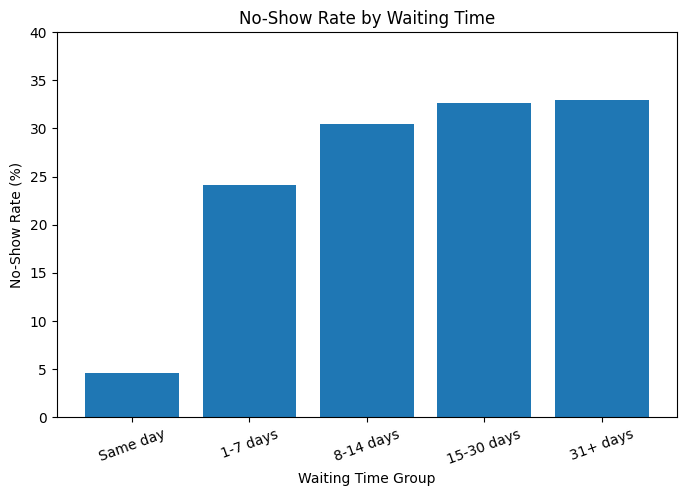

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(
    no_show_by_waiting_time["waiting_time_group"],
    no_show_by_waiting_time["no_show_rate_percent"]
)

plt.title("No-Show Rate by Waiting Time")
plt.xlabel("Waiting Time Group")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=20)
plt.ylim(0, 40)

plt.savefig("../Visuals/no_show_by_waiting_time.png", bbox_inches="tight")
plt.show()

### No-Show Rate by Age Group

Next, I compared no-show rates across patient age groups to identify whether certain demographic segments are more likely to miss appointments.

This can help clinics and healthcare products determine whether reminder or outreach strategies should be tailored to specific patient populations.

In [27]:
# Calculate no-show rate by age group
no_show_by_age_group = (
    df.groupby("age_group", observed=False)["no_show_flag"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)

no_show_by_age_group.columns = ["age_group", "no_show_rate_percent"]

no_show_by_age_group

,age_group,no_show_rate_percent
0,0-12,20.5
1,13-18,26.1
2,19-35,23.8
3,36-50,20.3
4,51-65,16.5
5,66+,15.5


#### Insight

No-show rates vary across age groups.  

Patients aged **13–18** have the highest no-show rate at **26.1%**, followed by patients aged **19–35** at **23.8%**. In contrast, older adults show lower no-show rates, with patients aged **66+** having the lowest rate at **15.5%**.  

This suggests that younger patient groups may benefit from more targeted reminder, confirmation, or rescheduling support.

#### Visualization: No-Show Rate by Age Group

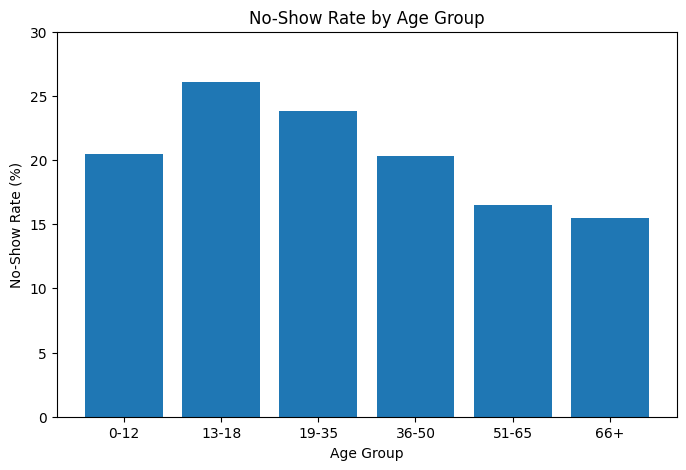

In [28]:
# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    no_show_by_age_group["age_group"],
    no_show_by_age_group["no_show_rate_percent"]
)

plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")
plt.ylim(0, 30)

plt.show()

### No-Show Rate by Appointment Weekday

I next examined whether missed appointments are more common on certain days of the week.

Understanding weekday patterns may help clinics improve scheduling decisions, allocate reminder efforts, or identify days that require additional operational support.

In [29]:
# Calculate no-show rate by appointment weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

no_show_by_weekday = (
    df.groupby("appointment_weekday")["no_show_flag"]
    .mean()
    .mul(100)
    .round(1)
    .reindex(weekday_order)
    .reset_index()
)

no_show_by_weekday.columns = ["appointment_weekday", "no_show_rate_percent"]

no_show_by_weekday

,appointment_weekday,no_show_rate_percent
0,Monday,20.6
1,Tuesday,20.1
2,Wednesday,19.7
3,Thursday,19.3
4,Friday,21.2
5,Saturday,23.1


#### Initial Observation

No-show rates are relatively similar across most weekdays, ranging from **19.3%** on Thursday to **21.2%** on Friday.  

Saturday has the highest observed no-show rate at **23.1%**, but this should be interpreted carefully. I next reviewed the number of appointments scheduled on each weekday to determine whether the Saturday rate is based on a sufficiently large volume of visits.

In [30]:
# Count appointment volume by weekday
appointments_by_weekday = (
    df["appointment_weekday"]
    .value_counts()
    .reindex(weekday_order)
    .reset_index()
)

appointments_by_weekday.columns = ["appointment_weekday", "appointment_count"]

appointments_by_weekday

,appointment_weekday,appointment_count
0,Monday,22713
1,Tuesday,25638
2,Wednesday,25866
3,Thursday,17246
4,Friday,19019
5,Saturday,39


#### Insight

Although Saturday shows the highest no-show rate at **23.1%**, it represents only **39 appointments**, which is far smaller than the weekday appointment volumes. Because of this limited sample size, the Saturday result should not be overinterpreted.

Among Monday through Friday, no-show rates are relatively similar, ranging from **19.3%** on Thursday to **21.2%** on Friday. This suggests that appointment weekday may have a weaker relationship with no-show behavior than factors such as waiting time or patient age group.

### No-Show Rate by SMS Reminder Status

I compared no-show rates between patients who received an SMS reminder and those who did not.

This variable is especially relevant from a product analytics perspective because reminder systems are a common operational intervention used to improve appointment attendance.

In [31]:
# Calculate no-show rate by SMS reminder status
no_show_by_sms = (
    df.groupby("sms_received")["no_show_flag"]
    .agg(
        appointment_count="count",
        no_show_rate="mean"
    )
    .reset_index()
)

no_show_by_sms["no_show_rate_percent"] = (
    no_show_by_sms["no_show_rate"] * 100
).round(1)

no_show_by_sms = no_show_by_sms[
    ["sms_received", "appointment_count", "no_show_rate_percent"]
]

no_show_by_sms

,sms_received,appointment_count,no_show_rate_percent
0,0,75039,16.7
1,1,35482,27.6


#### Initial Observation

Patients who received an SMS reminder show a higher no-show rate (**27.6%**) than patients who did not receive one (**16.7%**).  

However, this result should not be interpreted as evidence that SMS reminders increase no-shows. The relationship may be affected by confounding factors. For example, patients with appointments scheduled further in advance may be more likely to receive reminders, and longer waiting times were already associated with higher no-show rates in this dataset.

To better understand this pattern, I next compared waiting times between patients who received an SMS and those who did not.

In [32]:
# Compare average waiting time by SMS reminder status
waiting_time_by_sms = (
    df.groupby("sms_received")["waiting_days"]
    .agg(
        appointment_count="count",
        average_waiting_days="mean",
        median_waiting_days="median"
    )
    .round(1)
    .reset_index()
)

waiting_time_by_sms

,sms_received,appointment_count,average_waiting_days,median_waiting_days
0,0,75039,6.0,0.0
1,1,35482,19.0,14.0


#### Insight

Patients who received an SMS reminder had substantially longer scheduling lead times than those who did not.  

- Patients without an SMS reminder had an average waiting time of **6.0 days** and a median waiting time of **0 days**.
- Patients who received an SMS reminder had an average waiting time of **19.0 days** and a median waiting time of **14 days**.

Because longer waiting times were already associated with higher no-show rates, the higher no-show rate among SMS recipients should not be interpreted as evidence that reminders are ineffective. Instead, SMS receipt appears to be closely related to longer lead-time appointments, which may confound the simple comparison.

### No-Show Rate by SMS Status Within Waiting Time Groups

To reduce the effect of waiting time as a confounding factor, I compared no-show rates by SMS reminder status within each waiting time group.

This provides a more meaningful comparison than looking at SMS status alone, since patients who received reminders tended to have much longer scheduling lead times.

In [33]:
# Compare no-show rates by SMS status within each waiting time group
sms_by_waiting_group = (
    df.groupby(
        ["waiting_time_group", "sms_received"],
        observed=False
    )["no_show_flag"]
    .agg(
        appointment_count="count",
        no_show_rate="mean"
    )
    .reset_index()
)

sms_by_waiting_group["no_show_rate_percent"] = (
    sms_by_waiting_group["no_show_rate"] * 100
).round(1)

sms_by_waiting_group = sms_by_waiting_group[
    [
        "waiting_time_group",
        "sms_received",
        "appointment_count",
        "no_show_rate_percent"
    ]
]

sms_by_waiting_group

,waiting_time_group,sms_received,appointment_count,no_show_rate_percent
0,Same day,0,38562,4.6
1,Same day,1,0,NaN
2,1-7 days,0,20637,24.4
3,1-7 days,1,11548,23.8
4,8-14 days,0,5021,33.8
5,8-14 days,1,7004,28.1
6,15-30 days,0,6851,36.9
7,15-30 days,1,10520,29.8
8,31+ days,0,3968,37.5
9,31+ days,1,6410,30.2


#### Insight

After comparing SMS reminder status within the same waiting time groups, a clearer pattern emerges.  

For appointments scheduled more than one week in advance, patients who received an SMS reminder had noticeably lower no-show rates than patients who did not receive one:

- **8–14 days:** 28.1% with SMS vs. 33.8% without SMS
- **15–30 days:** 29.8% with SMS vs. 36.9% without SMS
- **31+ days:** 30.2% with SMS vs. 37.5% without SMS

This suggests that SMS reminders may be particularly valuable for appointments with longer scheduling lead times. The earlier unadjusted comparison was misleading because patients who received SMS reminders also tended to have much longer waiting times, which are independently associated with higher no-show rates.

From a product perspective, this supports using reminder workflows for appointments booked well in advance, especially when lead time exceeds one week.

#### Visualization: SMS Reminder Effect Within Waiting Time Groups

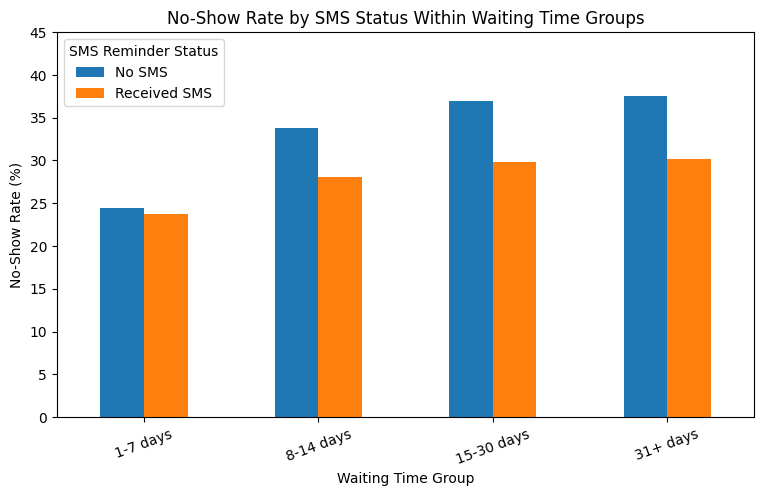

In [38]:
# Remove same-day appointments because no patients in that group received SMS reminders
sms_plot_data = sms_by_waiting_group[
    sms_by_waiting_group["waiting_time_group"] != "Same day"
].copy()

# Reshape the data for grouped bar chart
sms_plot_pivot = sms_plot_data.pivot(
    index="waiting_time_group",
    columns="sms_received",
    values="no_show_rate_percent"
)

# Rename legend labels
sms_plot_pivot.columns = ["No SMS", "Received SMS"]

# Create grouped bar chart
sms_plot_pivot.plot(kind="bar", figsize=(9, 5))

plt.title("No-Show Rate by SMS Status Within Waiting Time Groups")
plt.xlabel("Waiting Time Group")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=20)
plt.ylim(0, 45)
plt.legend(title="SMS Reminder Status")

plt.savefig("../Visuals/sms_within_waiting_time_groups.png", bbox_inches="tight")
plt.show()

## Key Findings Summary

Based on the exploratory analysis, several important patterns emerged:

1. **The overall no-show rate is 20.2%**, meaning roughly one in five appointments was missed.
2. **Waiting time is strongly associated with no-show behavior.** Same-day appointments have the lowest no-show rate, while appointments scheduled further in advance show substantially higher no-show rates.
3. **Younger patients are more likely to miss appointments.** Patients aged 13–18 and 19–35 have higher no-show rates than older patient groups.
4. **Weekday differences are relatively small** for Monday through Friday, suggesting that weekday alone may not be a major driver of no-show behavior.
5. **SMS reminder analysis requires careful interpretation.** A simple comparison suggests higher no-show rates among patients who received SMS reminders, but this is largely explained by longer waiting times. After comparing patients within the same waiting time groups, SMS reminders appear associated with lower no-show rates for appointments scheduled more than one week in advance.

These findings suggest that reminder and confirmation workflows may be most valuable for patients with longer scheduling lead times and for younger patient segments.

## Product Recommendations

Based on the findings, I would recommend the following product and operational actions:

- **Prioritize reminder workflows for longer lead-time appointments**, especially those scheduled more than 7 days in advance.
- **Use targeted reminder or confirmation strategies for younger patient groups**, who showed higher no-show rates.
- **Introduce proactive confirmation flows** for higher-risk appointments, such as SMS confirmation links or rescheduling prompts.
- **Monitor no-show rate by waiting time segment** as a core operational metric.
- **Evaluate reminder effectiveness using segmented analysis**, rather than relying only on overall averages.

In [35]:
# Save cleaned dataset
df.to_csv("../Data/processed/no_show_cleaned.csv", index=False)